# Разведочный анализ данных

## Цель работы
Провести предварительный анализ датасета с молекулярными дескрипторами и целевыми переменными:
- IC50, mM
- CC50, mM
- SI

## План
1. Загрузить данные.
2. Изучить размер таблицы, типы данных и пропуски.
3. Применить статистические методы к целевым переменным.
4. Исследовать выбросы.
5. Найти и удалить нерелевантные признаки.
6. Выполнить корреляционный анализ.
7. Сформулировать закономерности, упрощающие задачу.
8. Сделать выводы для дальнейшего моделирования.

## За основу берем материал из лекций следующих модулей:
- **Модуль 2** - работа с данными, пропусками, описательной статистикой, подготовкой к регрессии.
- **Модуль 6** - отбор признаков, интерпретируемость, анализ структуры признаков.
- **Модуль 8** - идеи снижения размерности и исследования структуры признакового пространства.



# 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

# 2. Загрузка данных

In [2]:
df = pd.read_excel("Данные_для_курсовои_Классическое_МО.xlsx")

print("Размер таблицы:", df.shape)
display(df.head())

Размер таблицы: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.

#3. Общая информация о датасете

In [3]:
print("Список столбцов:")
display(df.columns.tolist())

print("Типы данных:")
display(df.dtypes.value_counts())

print("Общая информация:")
df.info()

Список столбцов:


['Unnamed: 0',
 'IC50, mM',
 'CC50, mM',
 'SI',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SM

Типы данных:


,count
int64,107
float64,107


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


## Первичный просмотр данных

На этом этапе изучаются:
- размер таблицы;
- состав признаков;
- типы данных;
- общее устройство датасета.

По предварительному просмотру видно, что датасет в основном состоит из числовых молекулярных дескрипторов, что удобно для применения классических алгоритмов машинного обучения.

## Почему этот шаг важен

Первичный просмотр датасета позволяет понять, с каким типом данных предстоит работать дальше.  
Если большинство признаков числовые, можно использовать единый подход к предобработке и не тратить отдельный этап на кодирование

#4. Удаление служебного столбца

In [4]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Размер таблицы после удаления служебного столбца:", df.shape)
display(df.head())

Размер таблицы после удаления служебного столбца: (1001, 213)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.648545,11.47309

#5. Анализ пропусков

На этом этапе оценивается, насколько сильно пропуски могут повлиять на дальнейшее моделирование.  
Если в признаке слишком много пропусков, такой признак может быть нерелевантным или затруднять обучение моделей.  
Если пропусков немного, их можно будет заполнить устойчивыми статистиками, например медианой.

In [5]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percent": missing_percent
}).sort_values(by="Missing_Count", ascending=False)

display(missing_df[missing_df["Missing_Count"] > 0].head(30))

,Missing_Count,Missing_Percent
MinAbsPartialCharge,3,0.3
MaxPartialCharge,3,0.3
MinPartialCharge,3,0.3
MaxAbsPartialCharge,3,0.3
BCUT2D_MWHI,3,0.3
BCUT2D_MRLOW,3,0.3
BCUT2D_MRHI,3,0.3
BCUT2D_LOGPLOW,3,0.3
BCUT2D_LOGPHI,3,0.3
BCUT2D_CHGLO,3,0.3


## Анализ пропусков

Анализ пропусков нужен для того, чтобы заранее определить стратегию предобработки.  
Если пропусков немного, признаки можно сохранить и заполнить медианой.  
Если пропусков слишком много, признак может быть удалён как нерелевантный.  

#6. Описательная статистика

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000
MaxAbsEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
MaxEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
...,...,...,...,...,...,...,...,...
fr_thiazole,1001.0,0.051948,0.222033,0.000000,0.000000,0.000000,0.000000,1.000000
fr_thiocyan,1001.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,1001.0,0.069930,0.255157,0.000000,0.000000,0.000000,0.000000,1.000000
fr_unbrch_alkane,1001.0,0.204795,1.215326,0.000000,0.000000,0.000000,0.000000,20.000000


## Интерпретация описательной статистики

Описательная статистика позволяет оценить масштаб признаков, разброс значений и возможное наличие экстремальных наблюдений.  
На этом этапе уже можно заметить, что разные признаки имеют существенно различающиеся диапазоны значений, поэтому в дальнейшем для части моделей потребуется масштабирование.

#7. Выделение целевых переменных

In [7]:
targets = ["IC50, mM", "CC50, mM", "SI"]

for col in targets:
    print(f"{col} найден:", col in df.columns)

IC50, mM найден: True
CC50, mM найден: True
SI найден: True


#8. Статистический анализ целевых переменных

In [8]:
target_stats = pd.DataFrame({
    "mean": df[targets].mean(),
    "median": df[targets].median(),
    "std": df[targets].std(),
    "min": df[targets].min(),
    "max": df[targets].max(),
    "skew": df[targets].skew(),
    "kurtosis": df[targets].kurtosis(),
    "q1": df[targets].quantile(0.25),
    "q3": df[targets].quantile(0.75)
})

target_stats["iqr"] = target_stats["q3"] - target_stats["q1"]
display(target_stats)

,mean,median,std,min,max,skew,kurtosis,q1,q3,iqr
"IC50, mM",222.805156,46.585183,402.169734,0.003517,4128.529377,3.674929,22.450266,12.515396,224.975928,212.460532
"CC50, mM",589.110728,411.039342,642.867508,0.700808,4538.976189,1.973333,5.679448,99.999036,894.089176,794.090141
SI,72.508823,3.846154,684.482739,0.011489,15620.600000,18.013202,361.416696,1.433333,16.566667,15.133333


## Статистический анализ целевых переменных

Для целевых переменных рассчитаны:
- среднее значение;
- медиана;
- стандартное отклонение;
- квартили;
- межквартильный размах;
- асимметрия;
- эксцесс.

Это позволяет оценить форму распределения, наличие выбросов и ожидаемую сложность задачи моделирования.

#9. Распределения целевых переменных

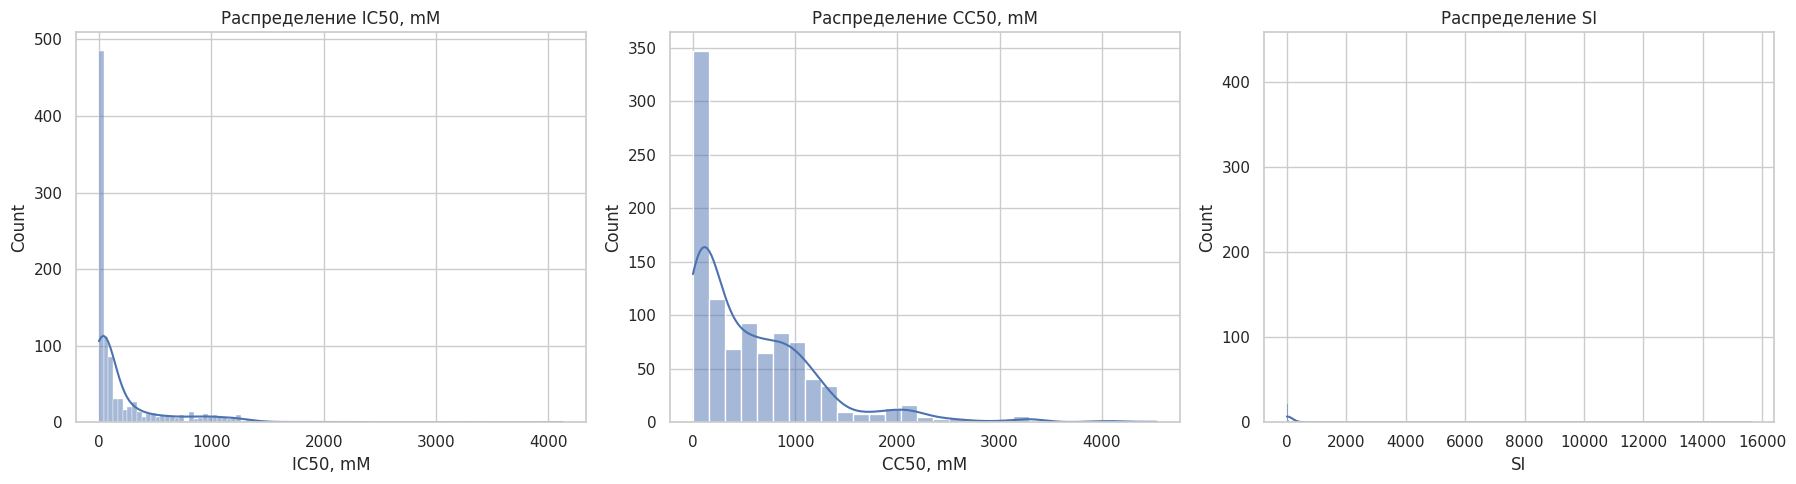

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(targets):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Распределение {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#10. Boxplot для целевых переменных

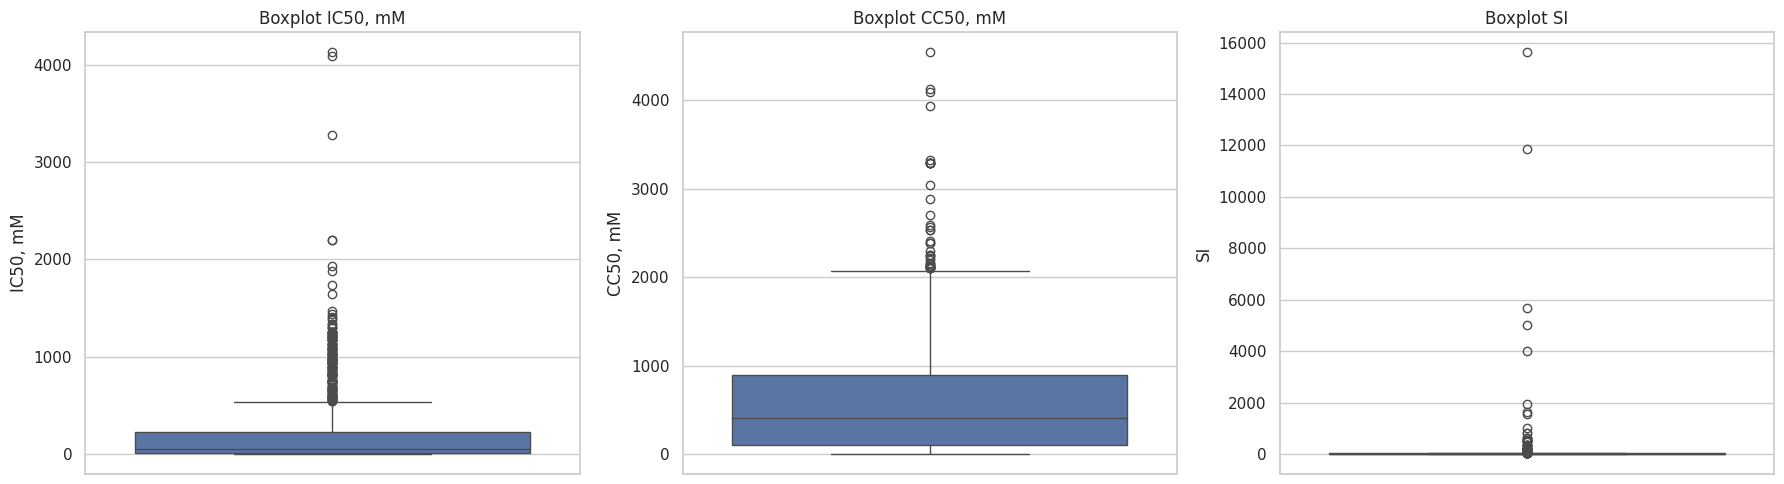

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(targets):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

#11. Асимметрия целевых переменных

In [11]:
print("Асимметрия целевых переменных:")
for col in targets:
    print(f"{col}: {df[col].skew():.4f}")

Асимметрия целевых переменных:
IC50, mM: 3.6749
CC50, mM: 1.9733
SI: 18.0132


#12. Подсчёт выбросов по IQR

In [12]:
outlier_info = []

for col in targets:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    outlier_info.append({
        "target": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outliers_count": outliers_count
    })

outlier_df = pd.DataFrame(outlier_info)
display(outlier_df)

,target,lower_bound,upper_bound,outliers_count
0,"IC50, mM",-306.175402,543.666725,147
1,"CC50, mM",-1091.136176,2085.224388,39
2,SI,-21.266667,39.266667,125


## Анализ выбросов

Для целевых переменных выбросы были определены на основе межквартильного размаха (IQR).  
Обнаруженные экстремальные значения учитываются при интерпретации сложности задач и выборе устойчивых моделей.

Полное удаление всех выбросов на данном этапе не выполняется автоматически, так как:
- выборка имеет ограниченный размер;
- экстремальные значения могут отражать реальные свойства химических соединений;
- удаление выбросов без предметной интерпретации может привести к потере значимой информации.

При этом факт наличия выбросов обязательно учитывается в дальнейших выводах.

#13. Поиск константных и почти константных признаков

In [13]:
constant_features = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
print("Константные признаки:", len(constant_features))
display(constant_features[:30])

near_constant_features = []
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False)
    if len(top_freq) > 0 and top_freq.iloc[0] > 0.99:
        near_constant_features.append(col)

print("Почти константные признаки:", len(near_constant_features))
display(near_constant_features[:30])

Константные признаки: 18


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_N_O',
 'fr_SH',
 'fr_azide',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitroso',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_thiocyan']

Почти константные признаки: 33


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_Ar_COO',
 'fr_HOCCN',
 'fr_N_O',
 'fr_SH',
 'fr_aldehyde',
 'fr_amidine',
 'fr_azide',
 'fr_azo',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_epoxide',
 'fr_guanido',
 'fr_hdrzine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitrile',
 'fr_nitroso',
 'fr_oxazole',
 'fr_oxime',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_sulfone',
 'fr_term_acetylene']

## Почему константные признаки считаются нерелевантными

Если признак принимает одно и то же значение почти для всех объектов, он практически не помогает различать наблюдения и не несёт полезной информации для модели.  
Поэтому такие признаки можно рассматривать как нерелевантные и удалять на этапе предварительной очистки данных.

#14. Поиск признаков с большим числом пропусков

In [14]:
high_missing_features = missing_df[missing_df["Missing_Percent"] > 30].index.tolist()
print("Признаки с пропусками более 30%:", len(high_missing_features))
display(high_missing_features[:30])

Признаки с пропусками более 30%: 0


[]

#15. Поиск сильно коррелирующих признаков

In [15]:
numeric_df = df.select_dtypes(include=["int64", "float64"]).copy()

corr_matrix = numeric_df.drop(columns=targets, errors="ignore").corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.95)
]

print("Сильно коррелирующие признаки (>|0.95|):", len(high_corr_features))
display(high_corr_features[:30])

Сильно коррелирующие признаки (>|0.95|): 33


['MaxEStateIndex',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'MinAbsPartialCharge',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'Kappa1',
 'Kappa2',
 'LabuteASA',
 'SlogP_VSA6',
 'HeavyAtomCount',
 'NumHAcceptors',
 'NumHDonors',
 'MolMR',
 'fr_Al_OH_noTert',
 'fr_COO',
 'fr_COO2',
 'fr_C_O_noCOO',
 'fr_Nhpyrrole',
 'fr_benzene']

## Почему удаляются сильно коррелирующие признаки

Если несколько признаков почти дублируют друг друга, это увеличивает избыточность данных и может затруднять интерпретацию результатов.  
Удаление части таких признаков уменьшает размерность пространства и делает дальнейший анализ более устойчивым.

# 16. Удаление нерелевантных признаков

In [16]:
features_to_drop = list(set(
    constant_features +
    high_missing_features +
    high_corr_features
))

features_to_drop = [col for col in features_to_drop if col in df.columns]
print("Всего признаков к удалению:", len(features_to_drop))
display(features_to_drop[:50])

df_eda_clean = df.drop(columns=features_to_drop, errors="ignore").copy()

print("Размер исходного датасета:", df.shape)
print("Размер после удаления нерелевантных признаков:", df_eda_clean.shape)

Всего признаков к удалению: 51


['MaxEStateIndex',
 'fr_phos_ester',
 'LabuteASA',
 'NumHDonors',
 'fr_Nhpyrrole',
 'Chi3n',
 'Kappa1',
 'Chi2v',
 'NumRadicalElectrons',
 'fr_phos_acid',
 'fr_barbitur',
 'MinAbsPartialCharge',
 'fr_lactam',
 'Chi1v',
 'fr_SH',
 'Kappa2',
 'fr_Al_OH_noTert',
 'fr_azide',
 'Chi0v',
 'NumValenceElectrons',
 'fr_phenol',
 'SlogP_VSA9',
 'fr_N_O',
 'HeavyAtomMolWt',
 'fr_COO2',
 'fr_nitroso',
 'Chi1',
 'Chi4v',
 'MolMR',
 'fr_phenol_noOrthoHbond',
 'fr_isothiocyan',
 'fr_benzene',
 'fr_dihydropyridine',
 'fr_diazo',
 'fr_isocyan',
 'Chi4n',
 'HeavyAtomCount',
 'NumHAcceptors',
 'ExactMolWt',
 'fr_COO',
 'fr_benzodiazepine',
 'Chi3v',
 'Chi0n',
 'fr_prisulfonamd',
 'Chi0',
 'SMR_VSA8',
 'fr_thiocyan',
 'fr_C_O_noCOO',
 'Chi1n',
 'SlogP_VSA6']

Размер исходного датасета: (1001, 213)
Размер после удаления нерелевантных признаков: (1001, 162)


## Удаление нерелевантных признаков

На основе предварительного анализа были найдены и удалены:
- константные признаки;
- признаки с большим числом пропусков;
- часть сильно коррелирующих признаков.

Удаление константных, сильно пропущенных и избыточно коррелирующих признаков уменьшает размерность признакового пространства.  
Это помогает:
- сократить шум;
- уменьшить переобучение;
- повысить интерпретируемость;
- упростить дальнейшее моделирование.

Этот шаг напрямую связан с **модулем 6**, где рассматривались feature selection и упрощение пространства признаков.

# 17. Корреляция между целевыми переменными

In [17]:
display(df_eda_clean[targets].corr())

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.521346,-0.056604
"CC50, mM",0.521346,1.000000,-0.006818
SI,-0.056604,-0.006818,1.000000


# 18. Pairplot целевых переменных

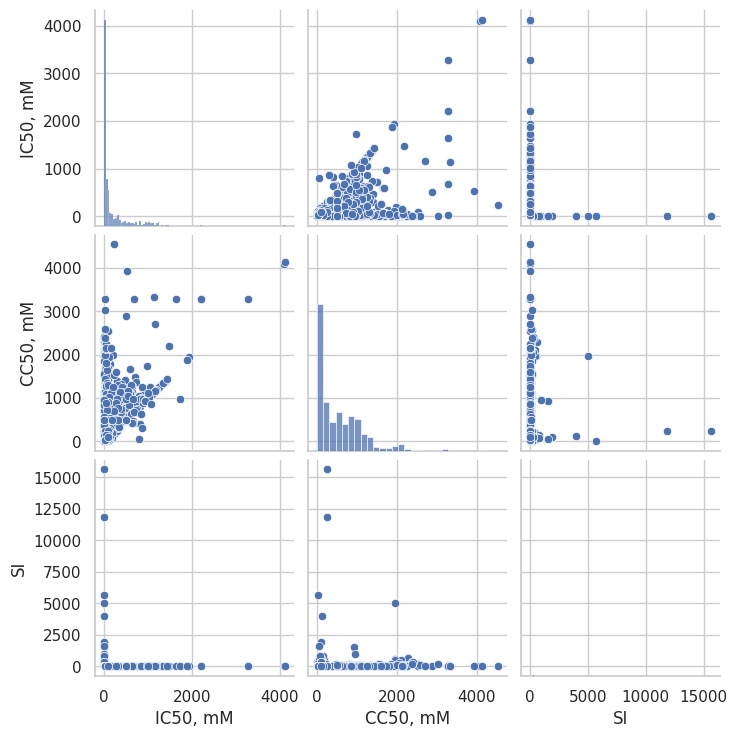

In [18]:
sns.pairplot(df_eda_clean[targets])
plt.show()

# 19. Топ признаков по корреляции с целевыми переменными

In [19]:
numeric_clean = df_eda_clean.select_dtypes(include=["int64", "float64"])
corr_clean = numeric_clean.corr()

for target in targets:
    print(f"\nТоп-15 признаков по модулю корреляции с {target}:")
    corr_target = corr_clean[target].drop(labels=targets, errors="ignore").sort_values(key=np.abs, ascending=False).head(15)
    display(corr_target)


Топ-15 признаков по модулю корреляции с IC50, mM:


,"IC50, mM"
VSA_EState4,-0.274203
Chi2n,-0.257058
PEOE_VSA7,-0.255988
fr_Ar_NH,0.245511
SlogP_VSA5,-0.236393
MolLogP,-0.218387
fr_nitro,0.215948
BCUT2D_LOGPHI,-0.211424
FpDensityMorgan1,0.208710
BCUT2D_CHGLO,0.204597



Топ-15 признаков по модулю корреляции с CC50, mM:


,"CC50, mM"
MolWt,-0.306439
Kappa3,-0.294513
FpDensityMorgan1,0.293989
BertzCT,-0.262327
NumAromaticCarbocycles,-0.258433
FpDensityMorgan2,0.256608
Chi2n,-0.254055
RingCount,-0.253273
PEOE_VSA7,-0.252945
SMR_VSA7,-0.235429



Топ-15 признаков по модулю корреляции с SI:


,SI
BalabanJ,0.162955
fr_NH2,0.160470
RingCount,-0.124444
fr_Al_COO,0.102414
NumAromaticRings,-0.088064
VSA_EState4,0.087837
FpDensityMorgan1,0.087341
VSA_EState6,-0.082995
NHOHCount,0.079143
NumAromaticCarbocycles,-0.078311


## Корреляционный анализ

Корреляционный анализ помогает:
- выявить наиболее связанные с целевой переменной дескрипторы;
- оценить, какие задачи потенциально будут решаться легче;
- понять, насколько переменные IC50, CC50 и SI различаются по сложности предсказания.

Если значимые корреляции с целевой переменной выражены слабо, это означает, что для хорошего качества могут понадобиться более гибкие нелинейные модели.

## Закономерности, упрощающие задачу

По результатам EDA были выявлены следующие особенности данных, упрощающие дальнейшее моделирование:

1. Датасет почти полностью состоит из числовых признаков, поэтому можно использовать единый пайплайн предобработки без сложного кодирования категориальных переменных.

2. Часть признаков оказалась нерелевантной:

- константные признаки;
- признаки с большим числом пропусков;
- часть сильно коррелирующих признаков.
  
Их удаление уменьшает размерность и снижает избыточность.

3. По корреляционному анализу видно, что IC50 и CC50 потенциально лучше поддаются моделированию, чем SI.

4. Распределение SI выглядит более сложным и содержит больше экстремальных значений, поэтому для этой целевой переменной ожидается более низкое качество моделей.

5. В классификационных постановках разбиение по медиане должно приводить к более сбалансированным классам, чем использование фиксированного порога SI > 8.

## Итоговый вывод по EDA

В рамках разведочного анализа данных был изучен набор молекулярных дескрипторов и целевых переменных IC50, mM, CC50, mM, SI.

### Что было сделано
- загружен и изучен датасет;
- удалён служебный столбец;
- проанализированы размеры таблицы, типы данных и пропуски;
- применены статистические методы к целевым переменным;
- исследованы распределения целевых переменных;
- проанализированы выбросы;
- найдены и удалены нерелевантные признаки;
- выполнен корреляционный анализ;
- выявлены закономерности, упрощающие дальнейшее моделирование.

### Основные результаты
- датасет почти полностью состоит из числовых признаков;
- часть признаков оказалась нерелевантной и была удалена;
- IC50 и CC50 потенциально лучше подходят для моделирования;
- SI выглядит наиболее сложной переменной с точки зрения распределения и устойчивости;
- перед построением моделей необходимо использовать предобработку данных и учитывать возможное влияние выбросов.


## Рекомендации для дальнейшего моделирования

1. Использовать очищенный набор признаков после удаления нерелевантных столбцов.
2. Проверить устойчивость моделей к выбросам.
3. Выполнить отбор наиболее информативных признаков.
4. При необходимости протестировать снижение размерности.
5. Для SI уделить особое внимание выбору модели и интерпретации результата, так как эта целевая переменная выглядит наиболее сложной.